In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D


In [3]:
before_df = pd.read_csv("embeddings_before.csv")
after_df  = pd.read_csv("embeddings_after.csv")
print(before_df.shape, after_df.shape)
before_df.head()


(9999, 1539) (9999, 1539)


,fraudulent_name,real_name,label,fraud_emb_0,real_emb_0,fraud_emb_1,real_emb_1,fraud_emb_2,real_emb_2,fraud_emb_3,...,fraud_emb_763,real_emb_763,fraud_emb_764,real_emb_764,fraud_emb_765,real_emb_765,fraud_emb_766,real_emb_766,fraud_emb_767,real_emb_767
0,meĝaĉriŧic,megacritic,1.0,-0.023890,0.021825,0.016651,0.020267,-0.014869,0.016880,-0.011270,...,0.017707,-0.003282,-0.004524,-0.003931,-0.011160,0.004199,-0.001346,0.011266,0.022872,0.001256
1,thedodo,queveohoy,0.0,0.021202,0.000160,-0.015211,0.022168,0.006032,0.002058,-0.006349,...,0.021103,0.006268,-0.015559,-0.002511,0.005688,-0.003988,0.009917,0.020676,0.017553,0.004817
2,alrnundoz,almundo,1.0,-0.022880,-0.019270,0.002446,-0.004138,0.013448,-0.006505,-0.030238,...,0.004297,0.028641,0.006351,-0.001470,0.004545,-0.009289,0.015647,-0.000266,0.003101,0.019192
3,nijobs,topjobs,0.0,-0.007072,-0.014049,0.004949,-0.011001,0.008215,0.035675,-0.001819,...,-0.016328,-0.007109,0.000837,-0.020542,0.019464,0.003099,0.001356,-0.025912,0.033526,-0.013195
4,trhonethrow,thronethrow,1.0,0.017048,0.023619,0.031167,0.000322,0.015982,0.014850,-0.016643,...,-0.008960,-0.002798,-0.013407,-0.002387,0.017236,0.048162,-0.018915,-0.004335,0.002787,-0.010348


In [4]:

fraud_cols = [c for c in before_df.columns if c.startswith("fraud_emb_")]
real_cols  = [c for c in before_df.columns if c.startswith("real_emb_")]

fraud_before = before_df[fraud_cols].values
real_before  = before_df[real_cols].values

fraud_after = after_df[fraud_cols].values
real_after  = after_df[real_cols].values

print(fraud_before.shape, fraud_after.shape)


(9999, 768) (9999, 768)


In [5]:
pca = PCA(n_components=3, random_state=42)

all_embeddings = np.vstack([
    fraud_before,
    real_before,
    fraud_after,
    real_after
])

pca.fit(all_embeddings)

fraud_before_pca = pca.transform(fraud_before)
real_before_pca  = pca.transform(real_before)

fraud_after_pca = pca.transform(fraud_after)
real_after_pca  = pca.transform(real_after)


In [6]:
final_df = before_df.copy()

sample_idx = final_df.sample(n=5, random_state=3).index

fraud_pca_sample = fraud_after_pca[sample_idx]
real_pca_sample  = real_after_pca[sample_idx]

fraud_words = final_df.loc[sample_idx, "fraudulent_name"].values
real_words  = final_df.loc[sample_idx, "real_name"].values

colors = plt.cm.tab10(np.linspace(0, 1, len(sample_idx)))


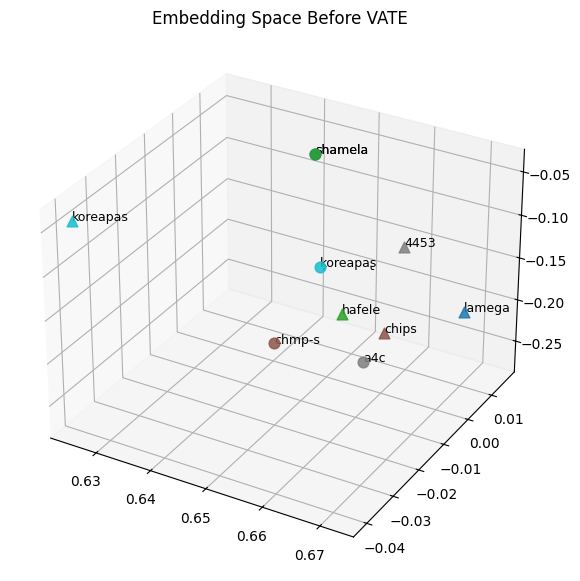

In [7]:

sample_idx = after_df.sample(n=5, random_state=3).index
fraud_words = after_df.loc[sample_idx, "fraudulent_name"].values
real_words  = after_df.loc[sample_idx, "real_name"].values
colors = plt.cm.tab10(np.linspace(0, 1, len(sample_idx)))

fraud_before_s = fraud_after_pca[sample_idx]
real_before_s  = real_after_pca[sample_idx]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for i, color in enumerate(colors):
    ax.scatter(*fraud_before_s[i], color=color, s=60, alpha=0.85)
    ax.scatter(*real_before_s[i],  color=color, s=60, alpha=0.85, marker="^")

    ax.text(*fraud_before_s[i], fraud_words[i], fontsize=9)
    ax.text(*real_before_s[i],  real_words[i],  fontsize=9)

ax.set_title("Embedding Space Before VATE")
x_lims = ax.get_xlim()
y_lims = ax.get_ylim()
z_lims = ax.get_zlim()

x_ticks = ax.get_xticks()
y_ticks = ax.get_yticks()
z_ticks = ax.get_zticks()

plt.show()


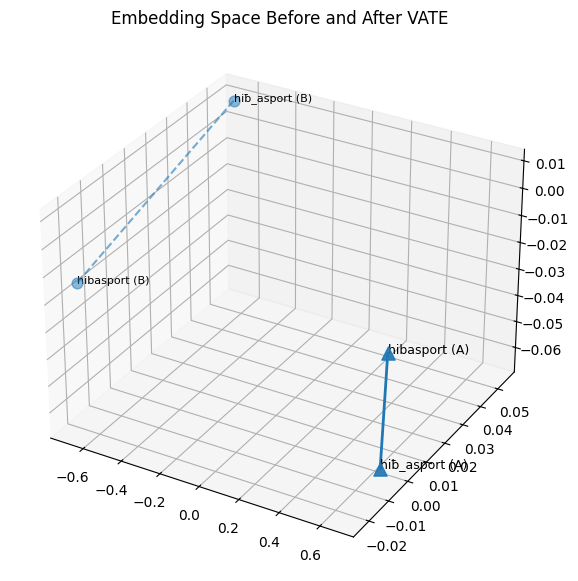

In [ ]:

before_df = pd.read_csv("embeddings_before.csv")
after_df  = pd.read_csv("embeddings_after.csv")

fraud_emb_cols = [c for c in before_df.columns if c.startswith("fraud_emb_")]
real_emb_cols  = [c for c in before_df.columns if c.startswith("real_emb_")]

fraud_before = before_df[fraud_emb_cols].to_numpy()
real_before  = before_df[real_emb_cols].to_numpy()

fraud_after  = after_df[fraud_emb_cols].to_numpy()
real_after   = after_df[real_emb_cols].to_numpy()

all_embeddings = np.vstack([
    fraud_before, real_before,
    fraud_after,  real_after
])

pca = PCA(n_components=3, random_state=0)
all_pca = pca.fit_transform(all_embeddings)

N = len(before_df)

fraud_before_pca = all_pca[0:N]
real_before_pca  = all_pca[N:2*N]
fraud_after_pca  = all_pca[2*N:3*N]
real_after_pca   = all_pca[3*N:4*N]


sample_idx = before_df.sample(n=1).index.to_numpy()

fraud_names = before_df.loc[sample_idx, "fraudulent_name"].values
real_names  = before_df.loc[sample_idx, "real_name"].values

colors = plt.cm.tab10(np.linspace(0, 1, len(sample_idx)))


fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for i, color in enumerate(colors):
    b_f = fraud_before_pca[sample_idx[i]]
    b_r = real_before_pca[sample_idx[i]]
    a_f = fraud_after_pca[sample_idx[i]]
    a_r = real_after_pca[sample_idx[i]]

    ax.scatter(*b_f, color=color, s=60, alpha=0.5, marker="o")
    ax.scatter(*b_r, color=color, s=60, alpha=0.5, marker="o")

    ax.scatter(*a_f, color=color, s=90, alpha=0.9, marker="^")
    ax.scatter(*a_r, color=color, s=90, alpha=0.9, marker="^")

    ax.plot([b_f[0], b_r[0]], [b_f[1], b_r[1]], [b_f[2], b_r[2]],
            color=color, linestyle="--", alpha=0.6)

    ax.plot([a_f[0], a_r[0]], [a_f[1], a_r[1]], [a_f[2], a_r[2]],
            color=color, linewidth=2)
    
    ax.text(*b_f, fraud_names[i] + " (B)", fontsize=8)
    ax.text(*b_r, real_names[i] + " (B)", fontsize=8)
    ax.text(*a_f, fraud_names[i] + " (A)", fontsize=9)
    ax.text(*a_r, real_names[i] + " (A)", fontsize=9)

ax.set_title("Embedding Space Before and After VATE")

plt.show()


In [ ]:

before_df = pd.read_csv("embeddings_before.csv")
after_df  = pd.read_csv("embeddings_after.csv")

fraud_cols = [c for c in before_df.columns if c.startswith("fraud_emb_")]
real_cols  = [c for c in before_df.columns if c.startswith("real_emb_")]

fraud_before = before_df[fraud_cols].to_numpy()
real_before  = before_df[real_cols].to_numpy()
fraud_after  = after_df[fraud_cols].to_numpy()
real_after   = after_df[real_cols].to_numpy()


dist_before = np.linalg.norm(fraud_before - real_before, axis=1)
dist_after  = np.linalg.norm(fraud_after  - real_after,  axis=1)

#some stats
print("BEFORE distances:")
print("  mean   =", dist_before.mean())
print("  median =", np.median(dist_before))
print("  std    =", dist_before.std())

print("\nAFTER distances:")
print("  mean   =", dist_after.mean())
print("  median =", np.median(dist_after))
print("  std    =", dist_after.std())

print("\nChange (AFTER - BEFORE):")
print("  mean change   =", (dist_after - dist_before).mean())
print("  median change =", np.median(dist_after - dist_before))


BEFORE distances:
  mean   = 0.6040836984775108
  median = 0.6216443580137208
  std    = 0.1684309678488738

AFTER distances:
  mean   = 0.32616701784566615
  median = 0.3104993732597501
  std    = 0.12024623422001232

Change (AFTER − BEFORE):
  mean change   = -0.27791668063184455
  median change = -0.279587223678116


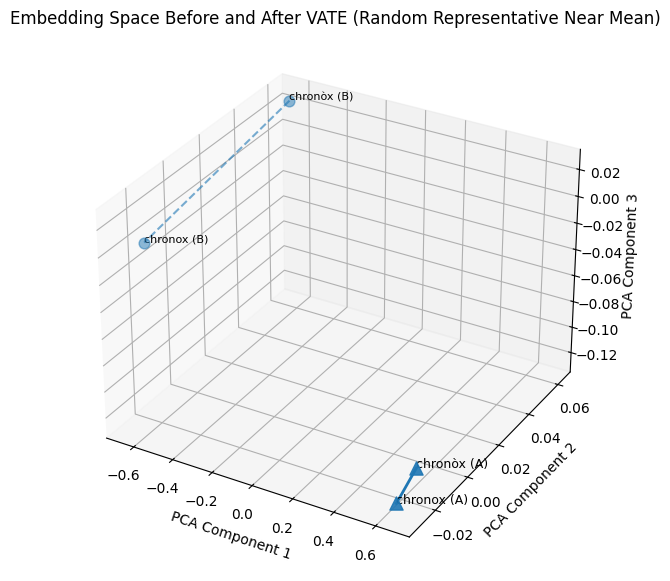

In [12]:

before_df = pd.read_csv("embeddings_before.csv")
after_df  = pd.read_csv("embeddings_after.csv")

fraud_emb_cols = [c for c in before_df.columns if c.startswith("fraud_emb_")]
real_emb_cols  = [c for c in before_df.columns if c.startswith("real_emb_")]

fraud_before = before_df[fraud_emb_cols].to_numpy()
real_before  = before_df[real_emb_cols].to_numpy()

fraud_after  = after_df[fraud_emb_cols].to_numpy()
real_after   = after_df[real_emb_cols].to_numpy()

dist_before = np.linalg.norm(fraud_before - real_before, axis=1)
dist_after  = np.linalg.norm(fraud_after  - real_after,  axis=1)
change = dist_after - dist_before

mean_change = change.mean()


window = 0.05 * abs(mean_change)  # 5% window around mean
candidate_idx = np.where(np.abs(change - mean_change) <= window)[0]

if len(candidate_idx) == 0:
    candidate_idx = np.arange(len(change))

sample_idx = np.random.choice(candidate_idx, size=1, replace=False)

all_embeddings = np.vstack([
    fraud_before, real_before,
    fraud_after,  real_after
])

pca = PCA(n_components=3, random_state=0)
all_pca = pca.fit_transform(all_embeddings)

N = len(before_df)

fraud_before_pca = all_pca[0:N]
real_before_pca  = all_pca[N:2*N]
fraud_after_pca  = all_pca[2*N:3*N]
real_after_pca   = all_pca[3*N:4*N]

fraud_names = before_df.loc[sample_idx, "fraudulent_name"].values
real_names  = before_df.loc[sample_idx, "real_name"].values
colors = plt.cm.tab10(np.linspace(0, 1, len(sample_idx)))

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

for i, color in enumerate(colors):
    b_f = fraud_before_pca[sample_idx[i]]
    b_r = real_before_pca[sample_idx[i]]
    a_f = fraud_after_pca[sample_idx[i]]
    a_r = real_after_pca[sample_idx[i]]

    ax.scatter(*b_f, color=color, s=60, alpha=0.5, marker="o")
    ax.scatter(*b_r, color=color, s=60, alpha=0.5, marker="o")

    ax.scatter(*a_f, color=color, s=90, alpha=0.9, marker="^")
    ax.scatter(*a_r, color=color, s=90, alpha=0.9, marker="^")

    ax.plot([b_f[0], b_r[0]], [b_f[1], b_r[1]], [b_f[2], b_r[2]],
            color=color, linestyle="--", alpha=0.6)
    ax.plot([a_f[0], a_r[0]], [a_f[1], a_r[1]], [a_f[2], a_r[2]],
            color=color, linewidth=2)

    ax.text(*b_f, fraud_names[i] + " (B)", fontsize=8)
    ax.text(*b_r, real_names[i] + " (B)", fontsize=8)
    ax.text(*a_f, fraud_names[i] + " (A)", fontsize=9)
    ax.text(*a_r, real_names[i] + " (A)", fontsize=9)

ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")
ax.set_title("Embedding Space Before and After VATE (Random Representative Near Mean)")

plt.show()
